# Overall Results

Set `JOB_FOLDER` in the cell below to a completed job directory. The cell reads `results/_stats_cache.json` and `results/fitness_history.csv`, then plots global fitness history and the per-Sunday delta distribution against the random solution.


Loaded stats from: D:\Coding\FAKS\Mentor\working-sundays\results\GradZagreb1\results\_stats_cache.json
Cache metadata:
{'random_name': 'random_start.json', 'optimized_name': 'solution.json', 'rand_mtime': 1782469751.5595086, 'opt_mtime': 1782475111.2850537, 'created_at': '2026-06-26T11:58:48.207779+00:00'}
Overall stats:
{'random': 67.20474357919667, 'optimized': 82.50809534961562, 'delta': 15.303351770418942}
Execution timing:
- backend run: 1h 29m 37s (2026-06-26T12:29:11.009811+02:00 -> 2026-06-26T13:58:48.209144+02:00)
- java process: 1h 29m 20s (2026-06-26T12:29:11.010685+02:00 -> 2026-06-26T13:58:31.357655+02:00)


,metric,started_at,finished_at,duration_seconds,source,reliability
0,backend run,2026-06-26 12:29:11.009811+02:00,2026-06-26 13:58:48.209144+02:00,5377.199333,descriptor.job run_info,persisted for new runs
1,java process,2026-06-26 12:29:11.010685+02:00,2026-06-26 13:58:31.357655+02:00,5360.346970,descriptor.job run_info,persisted for new runs


,sunday,random,optimized,delta,delta_pct,sunday_label
0,0,81.231588,89.331173,8.099585,9.970979,1
1,1,75.137108,91.987391,16.850283,22.426047,2
2,2,63.870314,78.056570,14.186256,22.211033,3
3,3,61.319985,73.138293,11.818308,19.273174,4
4,4,81.338938,69.705084,-11.633855,-14.302934,5


,step,iteration,fitness,global_fitness,best_global_fitness,incoming_alpha_fitness,elapsed_ms,timestamp_ms
0,1,0,67.223914,67.223914,67.223914,0.903972,1055,1782469752507
1,2,0,67.222770,67.222770,67.223914,0.886794,1156,1782469752608
2,3,0,67.120693,67.120693,67.223914,1.803454,1271,1782469752723
3,4,0,67.116693,67.116693,67.223914,0.885355,1376,1782469752828
4,5,0,67.117031,67.117031,67.223914,0.911914,1511,1782469752963


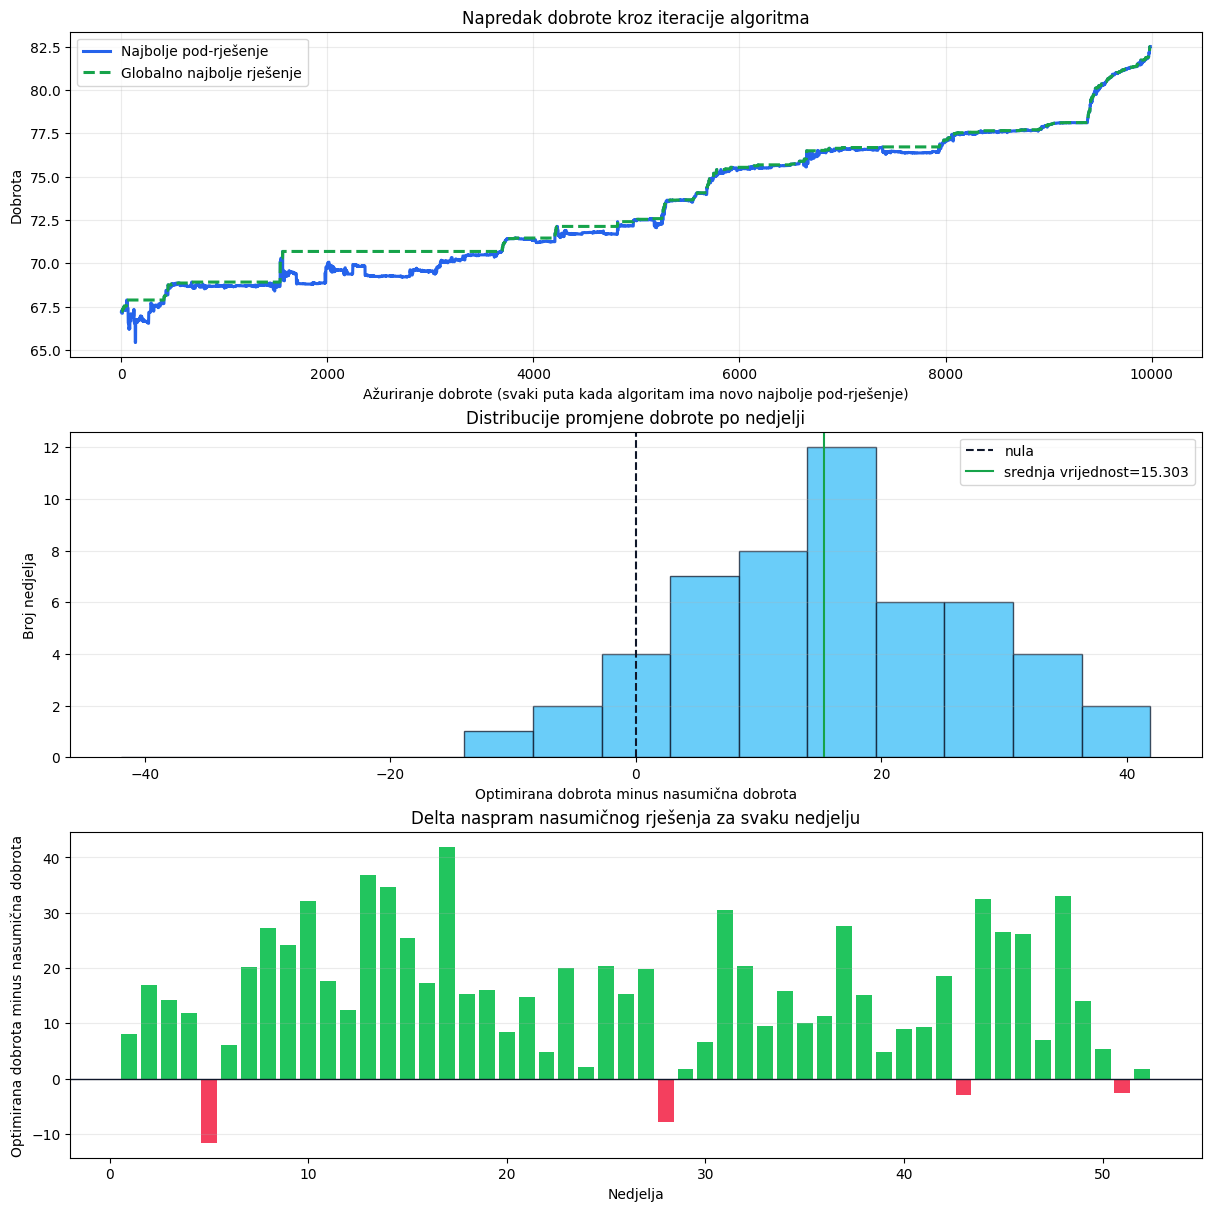

In [21]:
from pathlib import Path
from datetime import datetime, timezone
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

LOCAL_TZ = datetime.now().astimezone().tzinfo

# Edit this to point at a completed job folder, not the results folder.
# Example on Windows:
# JOB_FOLDER = Path(r"D:\\Coding\\FAKS\\Mentor\\working-sundays\\.sunday-cache\\jetpans\\d9a3343b-3665-403e-8b11-3c55aa63d381")
JOB_FOLDER = r"D:\Coding\FAKS\Mentor\working-sundays\results\GradZagreb1"


def load_stats_cache(job_folder):
    job_folder = Path(job_folder)
    cache_path = job_folder / "results" / "_stats_cache.json"
    if not cache_path.exists():
        raise FileNotFoundError(f"Stats cache not found: {cache_path}")

    payload = json.loads(cache_path.read_text(encoding="utf-8"))
    stats = payload.get("stats", payload)
    return payload, stats


def load_descriptor_run_info(job_folder):
    descriptor_path = Path(job_folder) / "descriptor.job"
    if not descriptor_path.exists():
        return {}

    descriptor = json.loads(descriptor_path.read_text(encoding="utf-8"))
    return descriptor.get("run_info") or {}


def parse_timestamp(value):
    if not value:
        return None
    if isinstance(value, (int, float)):
        return datetime.fromtimestamp(value, tz=LOCAL_TZ)
    try:
        parsed = datetime.fromisoformat(str(value))
    except ValueError:
        return None
    if parsed.tzinfo is None:
        return parsed.replace(tzinfo=LOCAL_TZ)
    return parsed.astimezone(LOCAL_TZ)


def file_timestamp(path, stat_name):
    path = Path(path)
    if not path.exists():
        return None
    value = getattr(path.stat(), stat_name, None)
    if value is None:
        return None
    return datetime.fromtimestamp(value, tz=LOCAL_TZ)


def seconds_between(start, finish):
    if not start or not finish:
        return None
    return max(0.0, (finish - start).total_seconds())


def estimate_execution_timing(job_folder):
    job_folder = Path(job_folder)
    run_info = load_descriptor_run_info(job_folder)
    solution_path = job_folder / "results" / "solution.json"

    started_at = parse_timestamp(run_info.get("started_at"))
    finished_at = parse_timestamp(run_info.get("finished_at"))
    java_started_at = parse_timestamp(run_info.get("java_started_at"))
    java_finished_at = parse_timestamp(run_info.get("java_finished_at"))

    rows = []
    if started_at or finished_at or run_info.get("duration_seconds") is not None:
        rows.append(
            {
                "metric": "backend run",
                "started_at": started_at,
                "finished_at": finished_at,
                "duration_seconds": run_info.get("duration_seconds") or seconds_between(started_at, finished_at),
                "source": "descriptor.job run_info",
                "reliability": "persisted for new runs",
            }
        )

    if java_started_at or java_finished_at or run_info.get("java_duration_seconds") is not None:
        rows.append(
            {
                "metric": "java process",
                "started_at": java_started_at,
                "finished_at": java_finished_at,
                "duration_seconds": run_info.get("java_duration_seconds") or seconds_between(java_started_at, java_finished_at),
                "source": "descriptor.job run_info",
                "reliability": "persisted for new runs",
            }
        )

    fallback_solution_finish = file_timestamp(solution_path, "st_mtime")
    if java_started_at and fallback_solution_finish and not java_finished_at:
        rows.append(
            {
                "metric": "java process estimate",
                "started_at": java_started_at,
                "finished_at": fallback_solution_finish,
                "duration_seconds": seconds_between(java_started_at, fallback_solution_finish),
                "source": "descriptor.job java_started_at -> results/solution.json mtime",
                "reliability": "best effort when java_finished_at is unavailable",
            }
        )

    return pd.DataFrame(rows)


def parse_fitness_history(job_folder):
    job_folder = Path(job_folder)
    history_path = job_folder / "results" / "fitness_history.csv"
    columns = [
        "step",
        "iteration",
        "fitness",
        "global_fitness",
        "best_global_fitness",
        "incoming_alpha_fitness",
        "elapsed_ms",
        "timestamp_ms",
    ]
    if not history_path.exists():
        return pd.DataFrame(columns=columns)

    df = pd.read_csv(history_path)
    required_columns = {"global_fitness", "best_global_fitness"}
    if df.empty or not required_columns.issubset(df.columns):
        return pd.DataFrame(columns=columns)

    numeric_columns = [
        "iteration",
        "global_fitness",
        "best_global_fitness",
        "incoming_alpha_fitness",
        "elapsed_ms",
        "timestamp_ms",
    ]
    for col in numeric_columns:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    df = df.dropna(subset=["global_fitness", "best_global_fitness"]).reset_index(drop=True)
    if df.empty:
        return pd.DataFrame(columns=columns)

    # Match the frontend chart: x is CSV update order, not algorithm iteration.
    # Final assembly rows can use iteration=-1, which makes an iteration x-axis misleading.
    df["step"] = df.index + 1
    df["fitness"] = df["global_fitness"]
    return df[[col for col in columns if col in df.columns]]


def stats_to_sunday_frame(stats):
    rows = []
    for entry in stats.get("per_sunday", []):
        random_value = float(entry.get("random", 0.0))
        optimized_value = float(entry.get("optimized", 0.0))
        delta = float(entry.get("delta", optimized_value - random_value))
        delta_pct = None if random_value == 0 else delta / abs(random_value) * 100.0
        rows.append(
            {
                "sunday": int(entry.get("sunday", len(rows))),
                "random": random_value,
                "optimized": optimized_value,
                "delta": delta,
                "delta_pct": delta_pct,
            }
        )

    df = pd.DataFrame(rows)
    if not df.empty:
        df["sunday_label"] = df["sunday"] + 1
    return df


def plot_fitness_history(fitness_df, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(10, 4))

    required_columns = {"step", "global_fitness", "best_global_fitness"}
    if fitness_df.empty or not required_columns.issubset(fitness_df.columns):
        ax.text(0.5, 0.5, "No fitness history found in fitness_history.csv", ha="center", va="center")
        ax.set_axis_off()
        return ax

    x = fitness_df["step"]
    after_incoming = fitness_df["global_fitness"]
    incumbent = fitness_df["best_global_fitness"]

    ax.plot(
        x,
        after_incoming,
        color="#2563eb",
        linewidth=2.2,
        label="Najbolje pod-rješenje",
    )
    ax.plot(
        x,
        incumbent,
        color="#16a34a",
        linestyle="--",
        linewidth=2.2,
        label="Globalno najbolje rješenje",
    )
    ax.set_title("Napredak dobrote kroz iteracije algoritma")
    ax.set_xlabel("Ažuriranje dobrote (svaki puta kada algoritam ima novo najbolje pod-rješenje)")
    ax.set_ylabel("Dobrota")
    ax.legend()
    ax.grid(True, alpha=0.25)
    return ax


def plot_delta_distribution(sunday_df, bins=None, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(10, 4))

    if sunday_df.empty:
        ax.text(0.5, 0.5, "No Sunday deltas available", ha="center", va="center")
        ax.set_axis_off()
        return ax

    deltas = sunday_df["delta"].to_numpy(dtype=float)
    max_abs = max(1.0, float(np.max(np.abs(deltas))))
    if bins is None:
        bin_count = min(17, max(7, int(np.ceil(np.sqrt(len(deltas)) * 2))))
        if bin_count % 2 == 0:
            bin_count += 1
        bins = np.linspace(-max_abs, max_abs, bin_count + 1)

    ax.hist(deltas, bins=bins, color="#38bdf8", edgecolor="#0f172a", alpha=0.75)
    ax.axvline(0, color="#0f172a", linestyle="--", linewidth=1.5, label="nula")
    ax.axvline(deltas.mean(), color="#16a34a", linestyle="-", linewidth=1.5, label=f"srednja vrijednost={deltas.mean():.3f}")
    ax.set_title("Distribucije promjene dobrote po nedjelji")
    ax.set_xlabel("Optimirana dobrota minus nasumična dobrota")
    ax.set_ylabel("Broj nedjelja")
    ax.legend()
    ax.grid(True, axis="y", alpha=0.25)
    return ax


def format_duration(seconds):
    if seconds is None or pd.isna(seconds):
        return "n/a"
    seconds = float(seconds)
    if seconds < 60:
        return f"{seconds:.2f}s"
    minutes, rem = divmod(seconds, 60)
    if minutes < 60:
        return f"{int(minutes)}m {rem:.1f}s"
    hours, minutes = divmod(minutes, 60)
    return f"{int(hours)}h {int(minutes)}m {rem:.0f}s"


def print_timing_summary(timing_df):
    if timing_df.empty:
        print("Execution timing: no persisted timing metadata found.")
        return

    print("Execution timing:")
    for _, row in timing_df.iterrows():
        duration = format_duration(row.get("duration_seconds"))
        started = row.get("started_at")
        finished = row.get("finished_at")
        started_text = started.isoformat() if pd.notna(started) else "n/a"
        finished_text = finished.isoformat() if pd.notna(finished) else "n/a"
        print(f"- {row.get('metric')}: {duration} ({started_text} -> {finished_text})")


def plot_delta_by_sunday(sunday_df, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(12, 4))

    if sunday_df.empty:
        ax.text(0.5, 0.5, "No Sunday deltas available", ha="center", va="center")
        ax.set_axis_off()
        return ax

    colors = np.where(sunday_df["delta"] >= 0, "#22c55e", "#f43f5e")
    ax.bar(sunday_df["sunday_label"], sunday_df["delta"], color=colors)
    ax.axhline(0, color="#0f172a", linewidth=1)
    ax.set_title("Delta naspram nasumičnog rješenja za svaku nedjelju")
    ax.set_xlabel("Nedjelja")
    ax.set_ylabel("Optimirana dobrota minus nasumična dobrota")
    ax.grid(True, axis="y", alpha=0.25)
    return ax


if JOB_FOLDER is None:
    print("Set JOB_FOLDER to a completed job directory, then run this cell.")
else:
    cache_payload, stats = load_stats_cache(JOB_FOLDER)
    timing_df = estimate_execution_timing(JOB_FOLDER)
    fitness_df = parse_fitness_history(JOB_FOLDER)
    sunday_df = stats_to_sunday_frame(stats)

    print(f"Loaded stats from: {Path(JOB_FOLDER) / 'results' / '_stats_cache.json'}")
    print("Cache metadata:")
    print({k: v for k, v in cache_payload.items() if k != "stats"})
    print("Overall stats:")
    print(stats.get("overall", {}))

    print_timing_summary(timing_df)
    if not timing_df.empty:
        display(timing_df)

    display(sunday_df.head())
    display(fitness_df.head())

    fig, axes = plt.subplots(3, 1, figsize=(12, 12), constrained_layout=True)
    plot_fitness_history(fitness_df, ax=axes[0])
    plot_delta_distribution(sunday_df, ax=axes[1])
    plot_delta_by_sunday(sunday_df, ax=axes[2])
    plt.show()


## Solution Similarity

This cell compares `OsjeckoBaranjska1` through `OsjeckoBaranjska5` pairwise. Fixed `works` assignments from `constraints.json` are removed before Jaccard similarity is calculated, because those assignments are mandatory rather than optimized decisions.


,job_a,job_b,job_a_optimized_assignments,job_b_optimized_assignments,job_a_fixed_works_removed,job_b_fixed_works_removed,shared_optimized_assignments,different_optimized_assignments,union_optimized_assignments,jaccard_similarity,jaccard_distance
0,OsjeckoBaranjska1,OsjeckoBaranjska3,1254,1254,1466,1466,762,984,1746,0.436426,0.563574
1,OsjeckoBaranjska3,OsjeckoBaranjska4,1254,1254,1466,1466,751,1006,1757,0.427433,0.572567
2,OsjeckoBaranjska1,OsjeckoBaranjska4,1254,1254,1466,1466,749,1010,1759,0.425810,0.574190
3,OsjeckoBaranjska1,OsjeckoBaranjska2,1254,1254,1466,1466,743,1022,1765,0.420963,0.579037
4,OsjeckoBaranjska3,OsjeckoBaranjska5,1254,1254,1466,1466,739,1030,1769,0.417750,0.582250
5,OsjeckoBaranjska2,OsjeckoBaranjska3,1254,1254,1466,1466,735,1038,1773,0.414552,0.585448
6,OsjeckoBaranjska1,OsjeckoBaranjska5,1254,1254,1466,1466,731,1046,1777,0.411367,0.588633
7,OsjeckoBaranjska2,OsjeckoBaranjska5,1254,1254,1466,1466,702,1104,1806,0.388704,0.611296
8,OsjeckoBaranjska2,OsjeckoBaranjska4,1254,1254,1466,1466,698,1112,1810,0.385635,0.614365
9,OsjeckoBaranjska4,OsjeckoBaranjska5,1254,1254,1466,1466,694,1120,1814,0.382580,0.617420


,OsjeckoBaranjska1,OsjeckoBaranjska2,OsjeckoBaranjska3,OsjeckoBaranjska4,OsjeckoBaranjska5
OsjeckoBaranjska1,1.000000,0.420963,0.436426,0.425810,0.411367
OsjeckoBaranjska2,0.420963,1.000000,0.414552,0.385635,0.388704
OsjeckoBaranjska3,0.436426,0.414552,1.000000,0.427433,0.417750
OsjeckoBaranjska4,0.425810,0.385635,0.427433,1.000000,0.382580
OsjeckoBaranjska5,0.411367,0.388704,0.417750,0.382580,1.000000


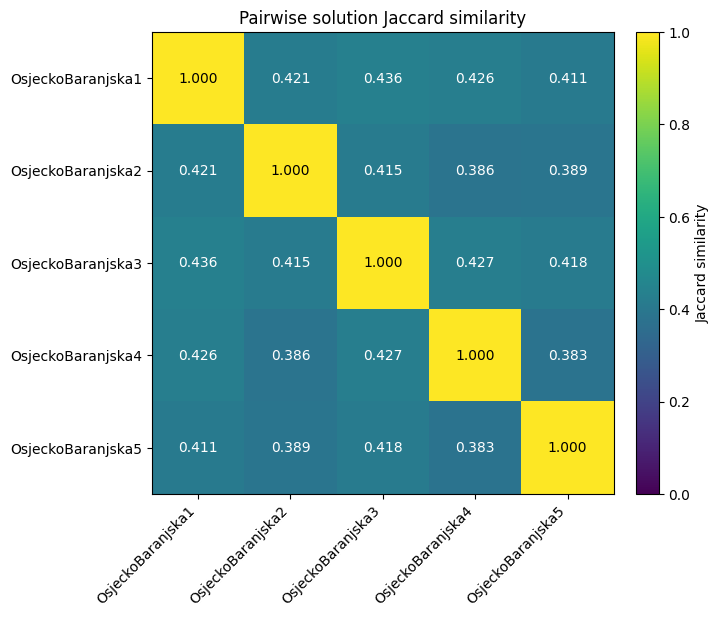

In [22]:
# Pairwise Jaccard similarity for OsjeckoBaranjska1..OsjeckoBaranjska5.
# Fixed mandatory works are removed before similarity is calculated.
SIMILARITY_BASE_FOLDER = Path(r"D:\Coding\FAKS\Mentor\working-sundays\results")
SIMILARITY_JOB_PREFIX = "OsjeckoBaranjska"
SIMILARITY_JOB_COUNT = 5


def load_solution_pairs(job_folder, result_name="solution.json"):
    solution_path = Path(job_folder) / "results" / result_name
    if not solution_path.exists():
        raise FileNotFoundError(f"Solution not found: {solution_path}")

    solution = json.loads(solution_path.read_text(encoding="utf-8"))
    pairs = set()
    for store_id, sundays in solution.items():
        if not isinstance(sundays, list):
            continue
        for sunday in sundays:
            pairs.add((str(store_id), int(sunday)))
    return pairs


def load_fixed_work_pairs(job_folder):
    constraints_path = Path(job_folder) / "constraints.json"
    if not constraints_path.exists():
        return set()

    constraints = json.loads(constraints_path.read_text(encoding="utf-8"))
    fixed_pairs = set()
    for store_id, payload in constraints.items():
        if not isinstance(payload, dict):
            continue
        for sunday in payload.get("works", []):
            fixed_pairs.add((str(store_id), int(sunday)))
    return fixed_pairs


def optimized_solution_pairs(job_folder):
    return load_solution_pairs(job_folder) - load_fixed_work_pairs(job_folder)


def jaccard_from_sets(pairs_a, pairs_b):
    union = pairs_a | pairs_b
    intersection = pairs_a & pairs_b
    jaccard = 1.0 if not union else len(intersection) / len(union)
    return {
        "shared_optimized_assignments": len(intersection),
        "different_optimized_assignments": len(pairs_a ^ pairs_b),
        "union_optimized_assignments": len(union),
        "jaccard_similarity": jaccard,
        "jaccard_distance": 1.0 - jaccard,
    }


def collect_similarity_jobs(base_folder, prefix, count):
    jobs = []
    for index in range(1, count + 1):
        name = f"{prefix}{index}"
        folder = Path(base_folder) / name
        if not folder.exists():
            raise FileNotFoundError(f"Job folder not found: {folder}")
        jobs.append((name, folder))
    return jobs


def pairwise_solution_jaccard(base_folder, prefix, count):
    jobs = collect_similarity_jobs(base_folder, prefix, count)
    optimized_pairs_by_name = {name: optimized_solution_pairs(folder) for name, folder in jobs}
    fixed_counts_by_name = {name: len(load_fixed_work_pairs(folder)) for name, folder in jobs}

    rows = []
    matrix = pd.DataFrame(np.eye(len(jobs)), index=[name for name, _ in jobs], columns=[name for name, _ in jobs])
    for i, (name_a, _) in enumerate(jobs):
        for j, (name_b, _) in enumerate(jobs):
            if j <= i:
                continue
            pairs_a = optimized_pairs_by_name[name_a]
            pairs_b = optimized_pairs_by_name[name_b]
            metrics = jaccard_from_sets(pairs_a, pairs_b)
            matrix.loc[name_a, name_b] = metrics["jaccard_similarity"]
            matrix.loc[name_b, name_a] = metrics["jaccard_similarity"]
            rows.append(
                {
                    "job_a": name_a,
                    "job_b": name_b,
                    "job_a_optimized_assignments": len(pairs_a),
                    "job_b_optimized_assignments": len(pairs_b),
                    "job_a_fixed_works_removed": fixed_counts_by_name[name_a],
                    "job_b_fixed_works_removed": fixed_counts_by_name[name_b],
                    **metrics,
                }
            )

    return pd.DataFrame(rows), matrix


def plot_jaccard_heatmap(matrix, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(7, 6))

    im = ax.imshow(matrix.to_numpy(dtype=float), vmin=0.0, vmax=1.0, cmap="viridis")
    ax.set_title("Pairwise solution Jaccard similarity")
    ax.set_xticks(range(len(matrix.columns)))
    ax.set_xticklabels(matrix.columns, rotation=45, ha="right")
    ax.set_yticks(range(len(matrix.index)))
    ax.set_yticklabels(matrix.index)

    for row in range(len(matrix.index)):
        for col in range(len(matrix.columns)):
            value = float(matrix.iloc[row, col])
            ax.text(col, row, f"{value:.3f}", ha="center", va="center", color="white" if value < 0.55 else "black")

    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Jaccard similarity")
    return ax


similarity_df, similarity_matrix = pairwise_solution_jaccard(
    SIMILARITY_BASE_FOLDER,
    SIMILARITY_JOB_PREFIX,
    SIMILARITY_JOB_COUNT,
)

display(similarity_df.sort_values("jaccard_similarity", ascending=False).reset_index(drop=True))
display(similarity_matrix)
plot_jaccard_heatmap(similarity_matrix)
plt.show()
